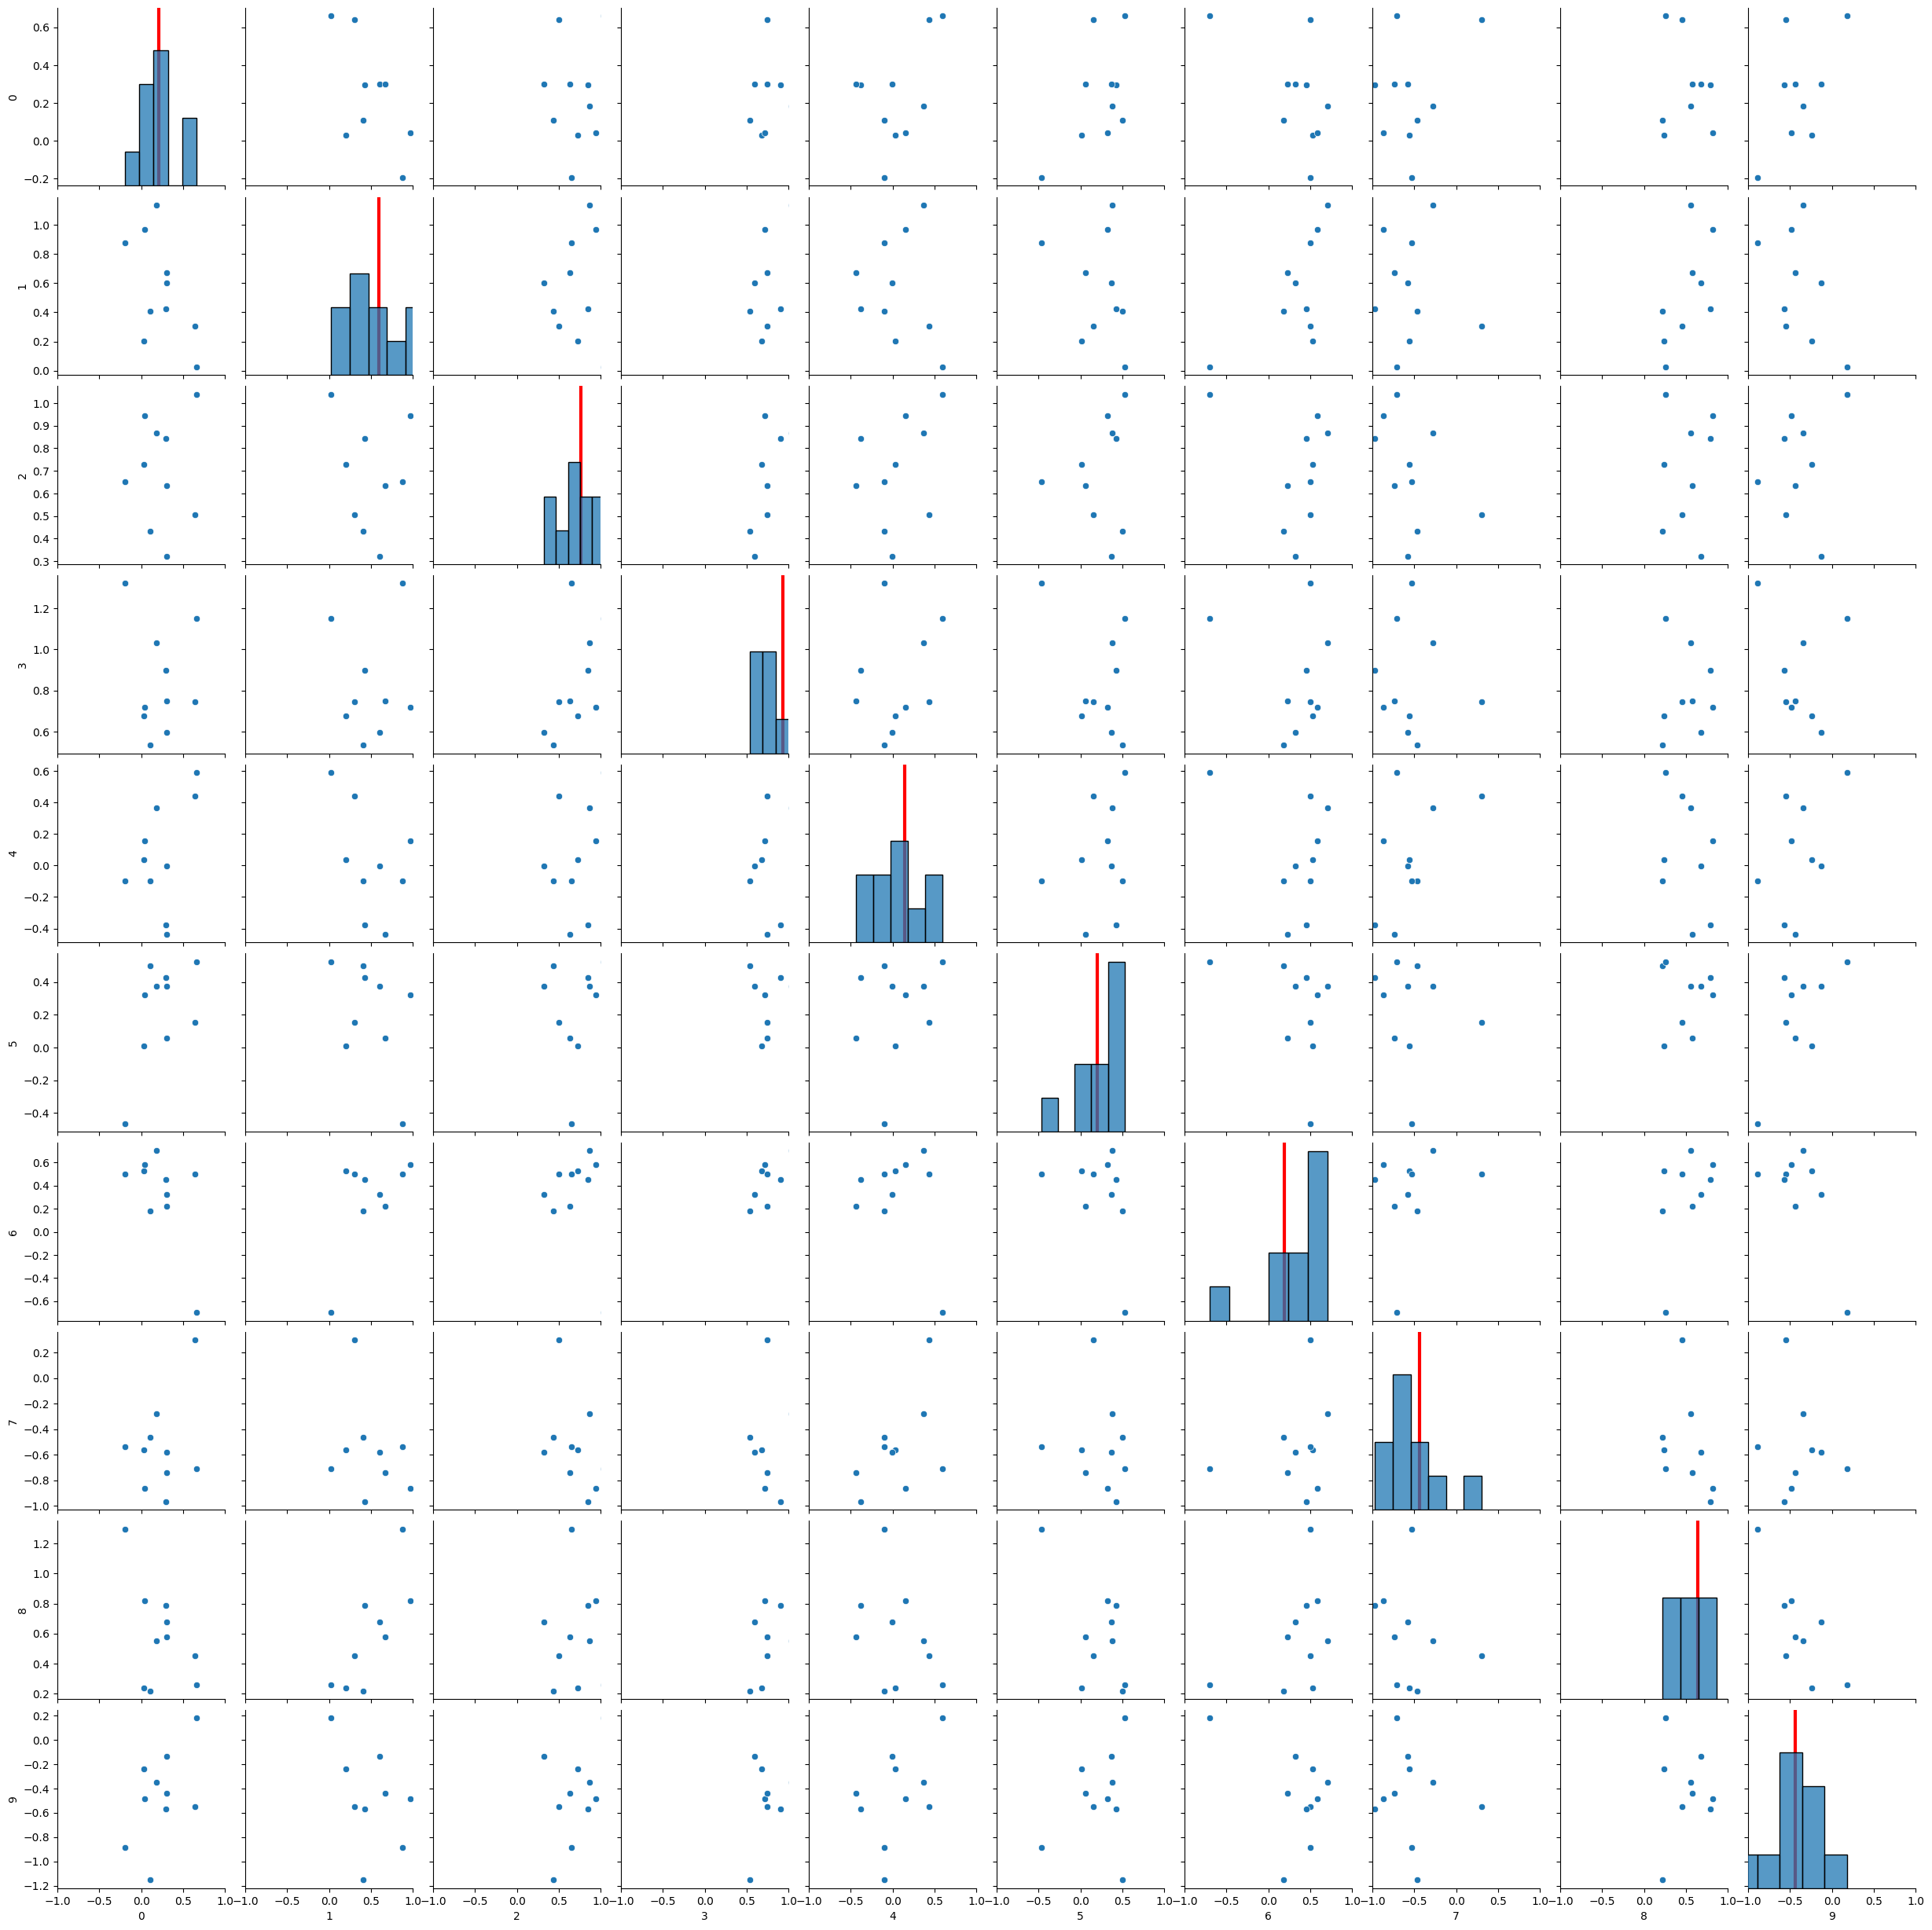

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import pickle
import sbi.utils as utils
import torch
from sbi.inference import MCMCPosterior
from scipy.special import logsumexp
from seaborn import histplot

import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import GLU, GLU_wrapper
import sbibm
from seaborn import pairplot
import warnings
warnings.simplefilter('ignore', FutureWarning)


prior = sbibm.get_task('gaussian_linear_uniform').get_prior_dist()
t = prior.sample((1,))[0]

X = GLU_wrapper(reps=10, parameters=t)
g = pairplot(pd.DataFrame(X.numpy()))
for i in range(len(t)):
    g.axes[i,i].axvline(t[i],color='red', linewidth=3)
    g.axes[i,i].set_xlim(prior.base_dist.low[i], prior.base_dist.high[i])

In [10]:
posterior_cp = pickle.load(open('posteriors/posterior_GLU_100000_20.pkl', 'rb'))
epsilon = -10000
op = CollectivePosterior(prior, X, posterior_cp, 1, epsilon)
print(op.get_log_C())

tensor(94.1417)


Rejection Sampling:   0%|          | 0/100 [00:00<?, ?it/s]/home/jupyter-nadavbennun/Nadav/Posterior/collective_posterior/GLU/../collective_posterior.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta, dtype=torch.float32)
Rejection Sampling: 101it [00:13,  7.69it/s]                        


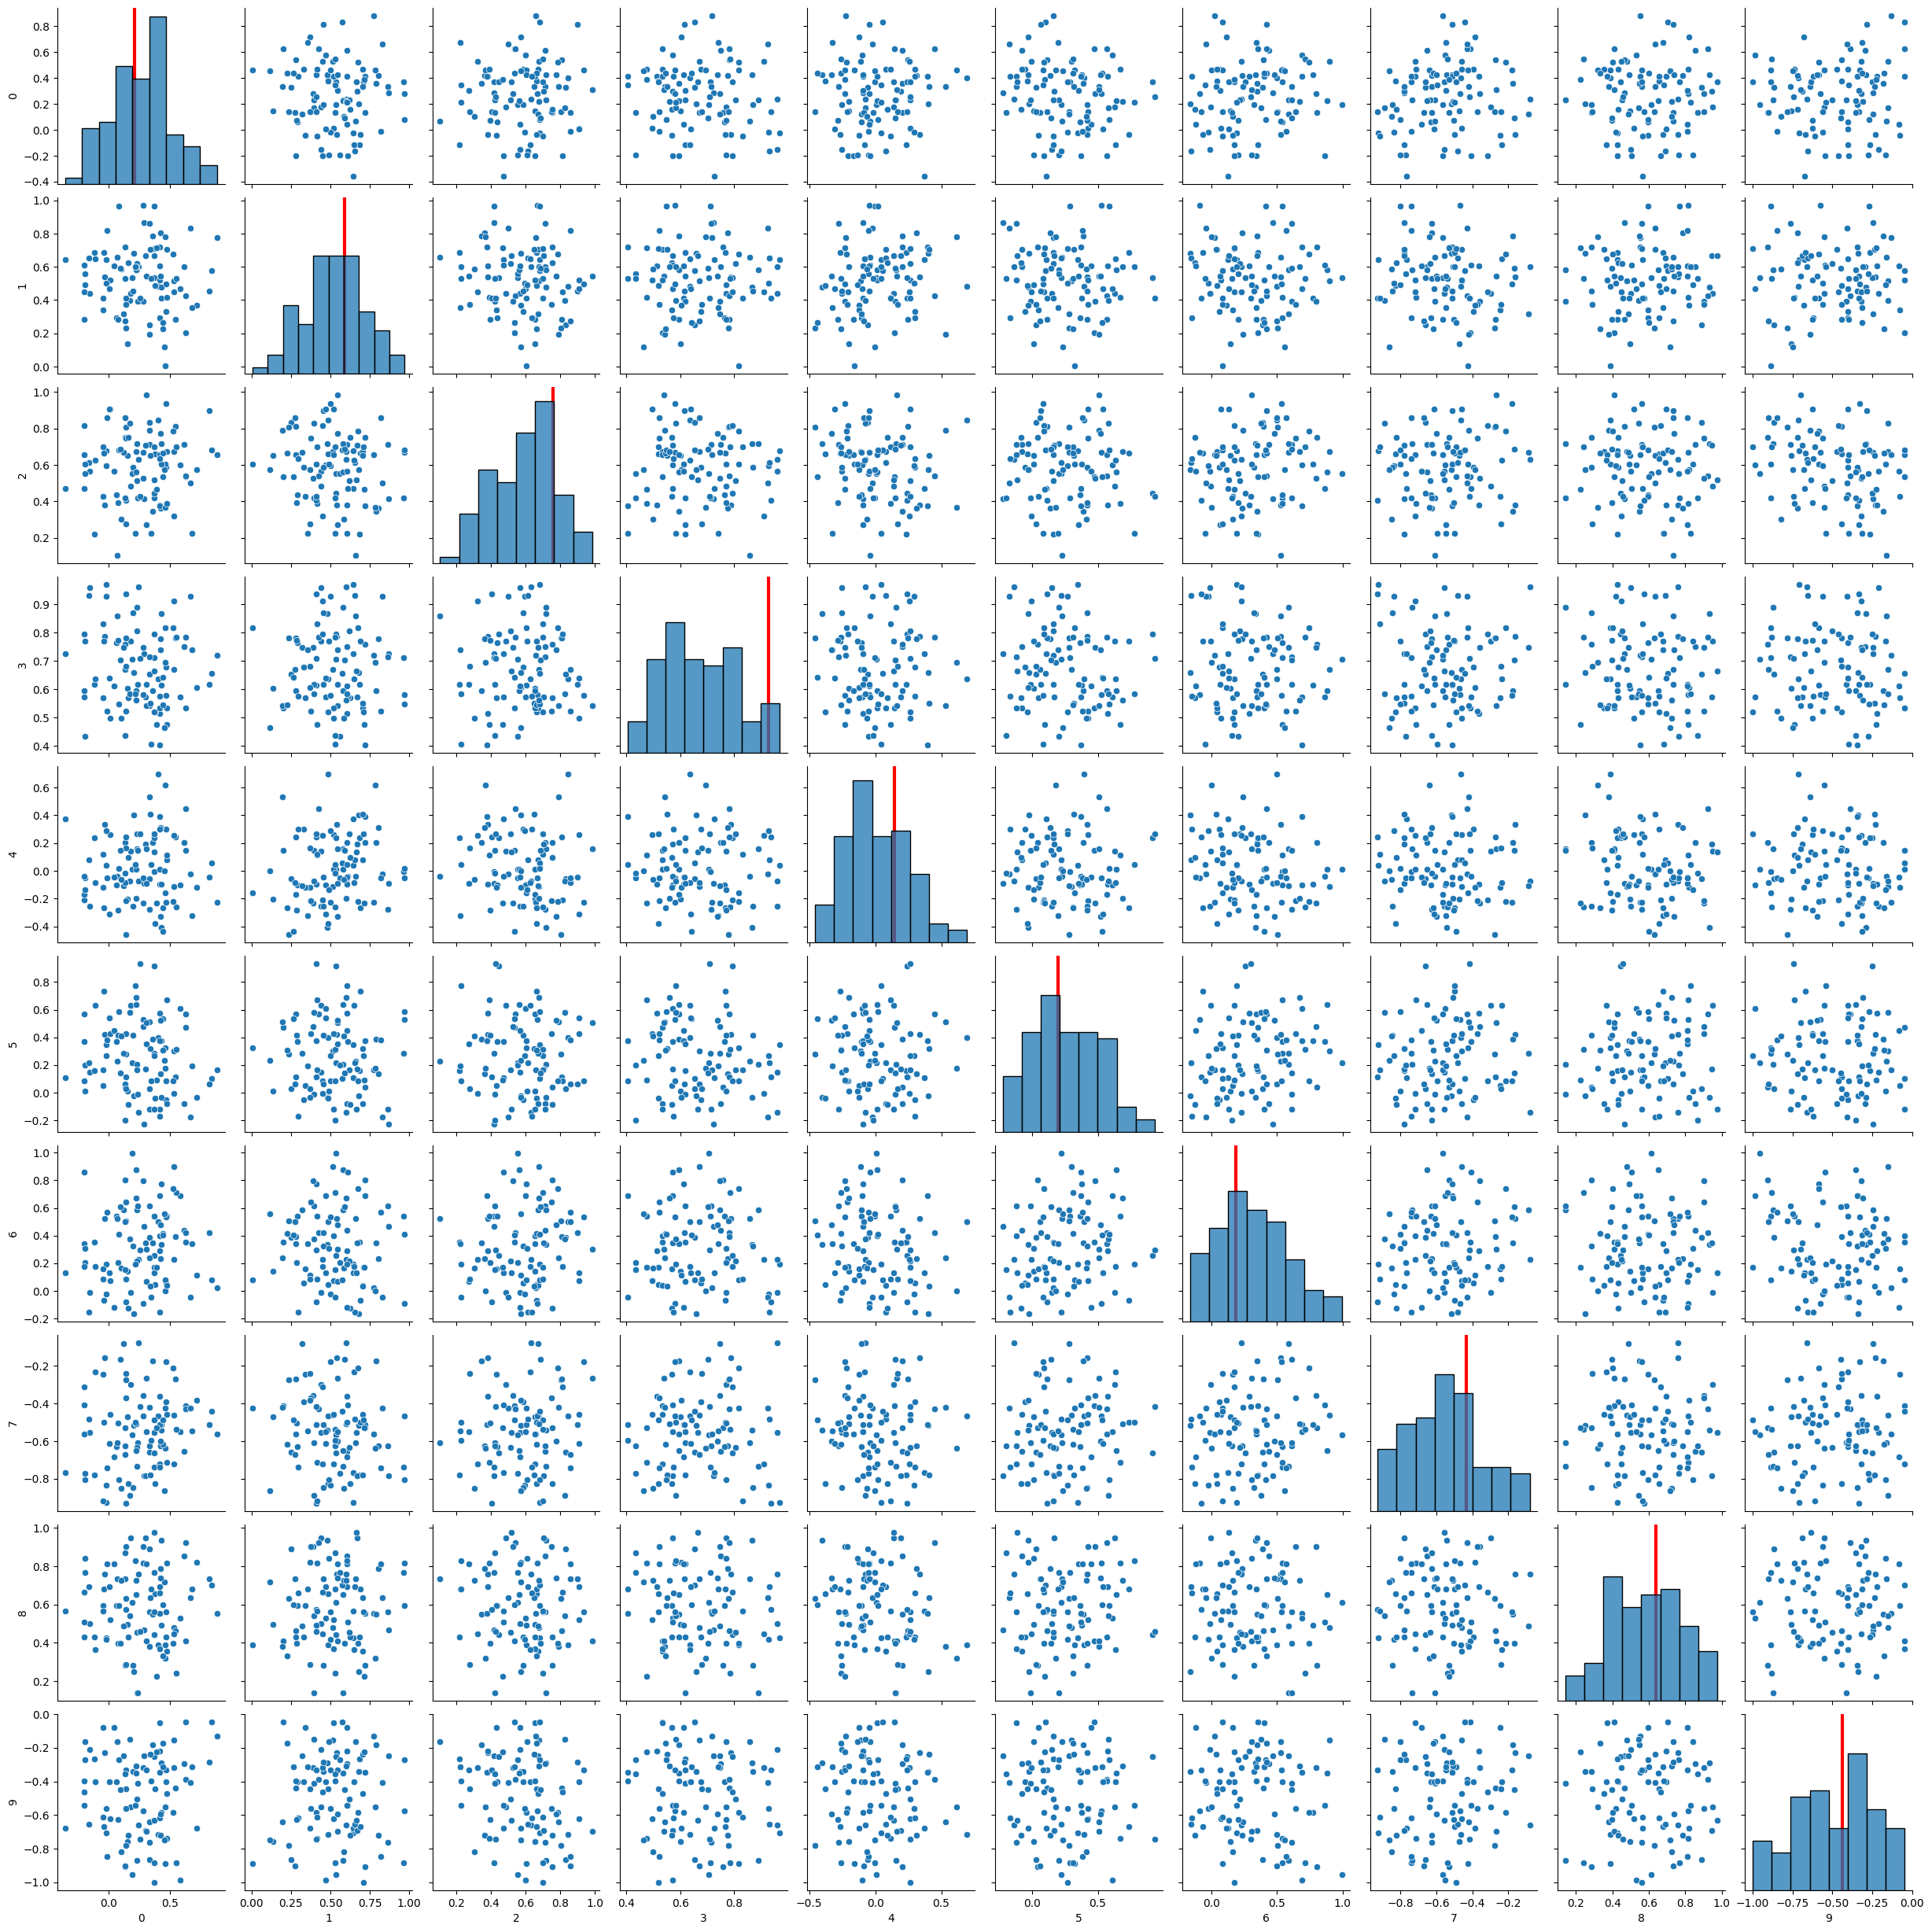

In [11]:
g = pairplot(pd.DataFrame(op.sample(100).numpy()))
for i in range(len(t)):
    g.axes[i,i].axvline(t[i],color='red', linewidth=3)

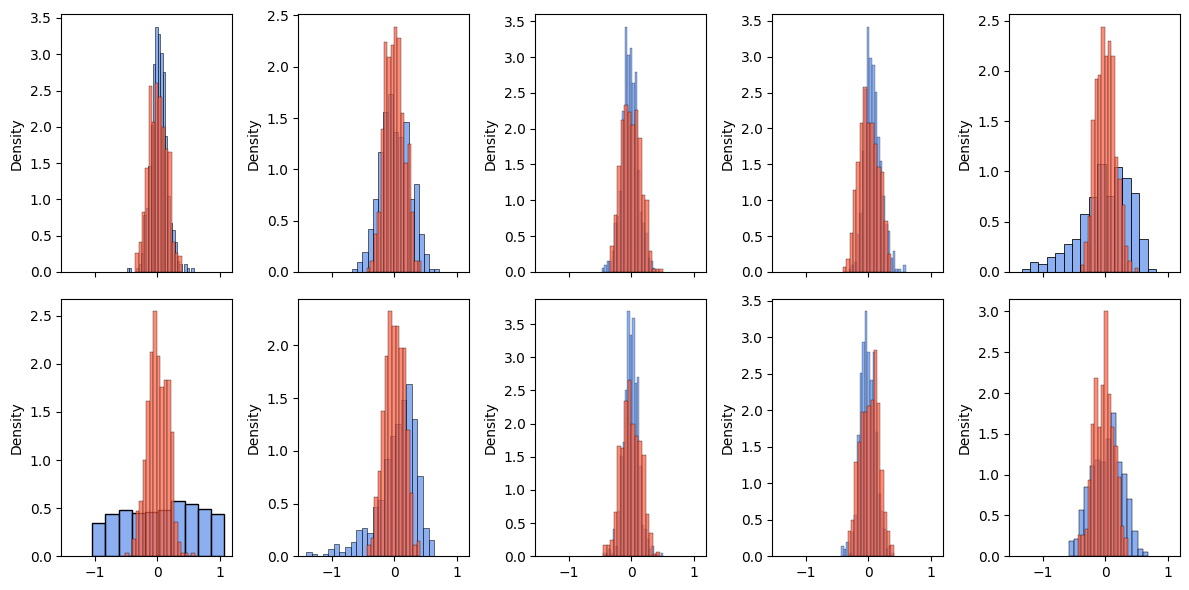

In [14]:
def plot_accuracy(acc_path, ax, color):
    res = pd.read_csv(acc_path, index_col=0, dtype='float')
    res = torch.from_numpy(np.array(res))
    for i in range(10):
        histplot(res[:,i],ax=ax[i%2, i//2], stat='density', color=color)
    return

n_params=10
fig, ax = plt.subplots(2,n_params//2, figsize=(12,6), tight_layout=True, sharex=True)


iid_acc = 'tests/accus_GLU_iid_r.csv'
plot_accuracy(iid_acc, ax, color='cornflowerblue')

cp_acc = 'tests/accus_GLU.csv'
plot_accuracy(cp_acc, ax, color='tomato')


In [7]:
covs_cp = pd.read_csv('tests/covs_old_GLU.csv', index_col=0)
covs_cp

,0,1,2,3,4,5,6,7,8,9
0.50,0.540,0.500,0.504,0.504,0.506,0.496,0.502,0.474,0.518,0.504
0.80,0.844,0.804,0.802,0.818,0.814,0.816,0.790,0.828,0.812,0.820
0.90,0.926,0.902,0.914,0.890,0.932,0.920,0.884,0.912,0.894,0.898
0.95,0.968,0.940,0.950,0.950,0.976,0.956,0.940,0.942,0.954,0.948


In [5]:
covs_iid = pd.read_csv('tests/covs_old_GLU_iid_r.csv', index_col=0)
covs_iid

,0,1,2,3,4,5,6,7,8,9
0.50,0.438,0.472,0.436,0.444,0.424,0.464,0.452,0.378,0.380,0.452
0.80,0.742,0.782,0.750,0.774,0.756,0.776,0.736,0.742,0.670,0.754
0.90,0.854,0.870,0.870,0.880,0.864,0.902,0.850,0.868,0.778,0.856
0.95,0.918,0.910,0.918,0.928,0.920,0.940,0.914,0.922,0.874,0.908
